# Overfitting and regularization

In this notebook we will look at various techniques to avoid overfitting.

We will start out by using the IMDB binary classification example from last time (ch 4 of the book). So let set that up and train the baseline model from last time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import layers

2026-03-04 11:52:41.597115: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-04 11:52:41.597175: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-04 11:52:41.599810: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-04 11:52:41.612682: I tensorflow/core/platform/cpu_feature_guard.cc:183] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

In [3]:
def multi_hot_encode(sequences, num_classes):
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0
    return results

x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)

y_train = train_labels.astype("float32")
y_test = test_labels.astype("float32")

x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [4]:
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

2026-03-04 11:52:50.598053: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1926] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20582 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:02:00.0, compute capability: 8.9


In [5]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20


2026-03-04 11:52:55.169288: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f3edc391550 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-04 11:52:55.169328: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2026-03-04 11:52:55.179734: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-04 11:52:55.246612: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:467] Loaded cuDNN version 90000
I0000 00:00:1772625175.377758  285342 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


30/30 [==============================] - 6s 79ms/step - loss: 0.5449 - accuracy: 0.7520 - val_loss: 0.3968 - val_accuracy: 0.8608
Epoch 2/20
30/30 [==============================] - 1s 20ms/step - loss: 0.2983 - accuracy: 0.9027 - val_loss: 0.3004 - val_accuracy: 0.8837
Epoch 3/20
30/30 [==============================] - 0s 15ms/step - loss: 0.2084 - accuracy: 0.9313 - val_loss: 0.2792 - val_accuracy: 0.8885
Epoch 4/20
30/30 [==============================] - 0s 15ms/step - loss: 0.1560 - accuracy: 0.9520 - val_loss: 0.2806 - val_accuracy: 0.8879
Epoch 5/20
30/30 [==============================] - 0s 17ms/step - loss: 0.1207 - accuracy: 0.9657 - val_loss: 0.2898 - val_accuracy: 0.8855
Epoch 6/20
30/30 [==============================] - 0s 16ms/step - loss: 0.0935 - accuracy: 0.9757 - val_loss: 0.3090 - val_accuracy: 0.8829
Epoch 7/20
30/30 [==============================] - 0s 15ms/step - loss: 0.0720 - accuracy: 0.9849 - val_loss: 0.3320 - val_accuracy: 0.8807
Epoch 8/20
30/30 [======

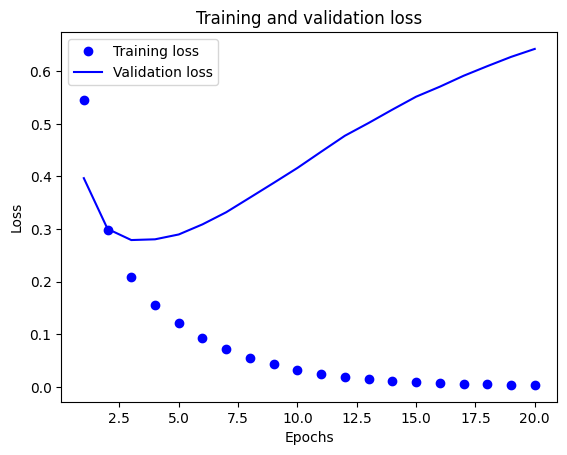

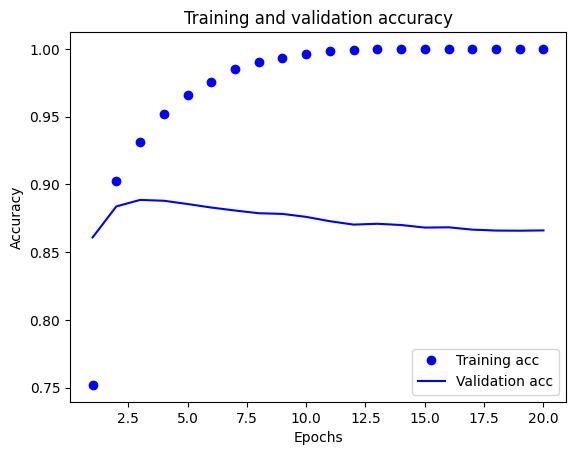

In [6]:
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]

epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.figure()
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [7]:
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.fit(x_train, y_train, epochs=3, batch_size=512)

test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.3f}")

Epoch 1/3
49/49 [==============================] - 2s 9ms/step - loss: 0.4563 - accuracy: 0.8166
Epoch 2/3
49/49 [==============================] - 0s 9ms/step - loss: 0.2733 - accuracy: 0.9032
Epoch 3/3
782/782 [==============================] - 2s 3ms/step - loss: 0.3092 - accuracy: 0.8733
Test accuracy: 0.873


## Early stopping

We can manually inspect the loss graph and stop the model when it reaches it min loss (here 3/4 epoch) or we can more systematically keep the model with the lowest validation loss using the ModelCheckpoint callback from Keras. First we set up callbacks.

In [8]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="imbd_overfitting_ex.keras",
        save_best_only=True,
        monitor="val_loss")
]

In [9]:
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [10]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val),
                    callbacks=callbacks)

Epoch 1/20
30/30 [==============================] - 4s 85ms/step - loss: 0.5668 - accuracy: 0.7465 - val_loss: 0.4256 - val_accuracy: 0.8482
Epoch 2/20
30/30 [==============================] - 1s 36ms/step - loss: 0.3209 - accuracy: 0.8950 - val_loss: 0.3089 - val_accuracy: 0.8837
Epoch 3/20
30/30 [==============================] - 1s 40ms/step - loss: 0.2204 - accuracy: 0.9269 - val_loss: 0.2839 - val_accuracy: 0.8872
Epoch 4/20
30/30 [==============================] - 1s 43ms/step - loss: 0.1692 - accuracy: 0.9449 - val_loss: 0.2822 - val_accuracy: 0.8878
Epoch 5/20
30/30 [==============================] - 1s 20ms/step - loss: 0.1322 - accuracy: 0.9602 - val_loss: 0.2860 - val_accuracy: 0.8870
Epoch 6/20
30/30 [==============================] - 0s 15ms/step - loss: 0.1054 - accuracy: 0.9710 - val_loss: 0.3011 - val_accuracy: 0.8832
Epoch 7/20
30/30 [==============================] - 0s 13ms/step - loss: 0.0844 - accuracy: 0.9796 - val_loss: 0.3191 - val_accuracy: 0.8818
Epoch 8/20
30

Now we can retreive the best model and evaluate it.

In [11]:
test_model = keras.models.load_model("imbd_overfitting_ex.keras")
test_loss, test_acc = test_model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.3f}")

782/782 [==============================] - 3s 3ms/step - loss: 0.3019 - accuracy: 0.8770
Test accuracy: 0.877


This corresponds to the best model we could have manually gotten.

## Weight regularization

Let us try to add weight regularization in the form of L1 and L2 regularization

In [12]:
from keras import regularizers

model = keras.Sequential([
    layers.Dense(16, activation="relu",
                kernel_regularizer=regularizers.l2(0.005)),
    layers.Dense(16, activation="relu",
                kernel_regularizer=regularizers.l2(0.005)),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [13]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=30,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/30
30/30 [==============================] - 5s 83ms/step - loss: 0.7171 - accuracy: 0.7711 - val_loss: 0.5477 - val_accuracy: 0.8469
Epoch 2/30
30/30 [==============================] - 1s 18ms/step - loss: 0.4650 - accuracy: 0.8861 - val_loss: 0.4505 - val_accuracy: 0.8806
Epoch 3/30
30/30 [==============================] - 1s 20ms/step - loss: 0.3915 - accuracy: 0.9115 - val_loss: 0.4263 - val_accuracy: 0.8846
Epoch 4/30
30/30 [==============================] - 1s 18ms/step - loss: 0.3581 - accuracy: 0.9232 - val_loss: 0.4153 - val_accuracy: 0.8847
Epoch 5/30
30/30 [==============================] - 0s 16ms/step - loss: 0.3379 - accuracy: 0.9289 - val_loss: 0.4139 - val_accuracy: 0.8822
Epoch 6/30
30/30 [==============================] - 0s 15ms/step - loss: 0.3219 - accuracy: 0.9361 - val_loss: 0.4095 - val_accuracy: 0.8813
Epoch 7/30
30/30 [==============================] - 1s 17ms/step - loss: 0.3091 - accuracy: 0.9391 - val_loss: 0.4086 - val_accuracy: 0.8815
Epoch 8/30
30

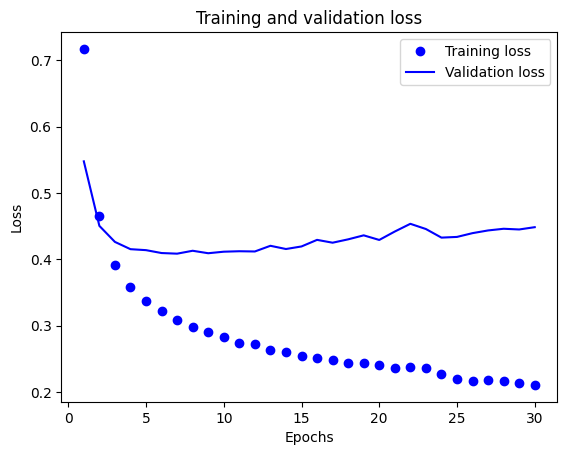

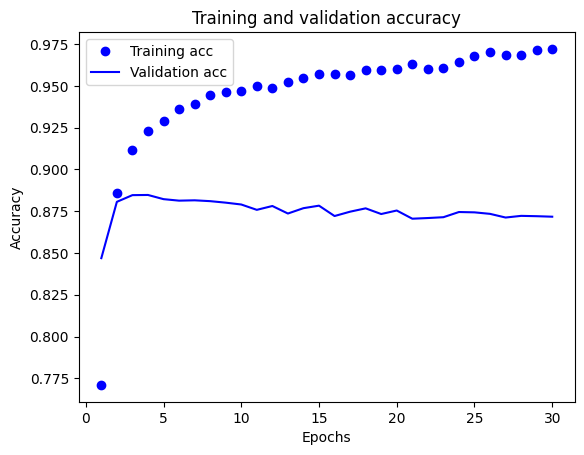

In [14]:
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]

epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.figure()
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

We see that the model starts to overfit later and to a less degree

We refit it on 10 epochs.

In [15]:
model = keras.Sequential([
    layers.Dense(16, activation="relu",
                kernel_regularizer=regularizers.l2(0.005)),
    layers.Dense(16, activation="relu",
                kernel_regularizer=regularizers.l2(0.005)),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=10,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/10
30/30 [==============================] - 5s 73ms/step - loss: 0.7103 - accuracy: 0.7712 - val_loss: 0.5490 - val_accuracy: 0.8625
Epoch 2/10
30/30 [==============================] - 1s 20ms/step - loss: 0.4818 - accuracy: 0.8833 - val_loss: 0.4570 - val_accuracy: 0.8812
Epoch 3/10
30/30 [==============================] - 1s 19ms/step - loss: 0.4115 - accuracy: 0.9034 - val_loss: 0.4599 - val_accuracy: 0.8656
Epoch 4/10
30/30 [==============================] - 1s 19ms/step - loss: 0.3792 - accuracy: 0.9138 - val_loss: 0.4181 - val_accuracy: 0.8873
Epoch 5/10
30/30 [==============================] - 1s 27ms/step - loss: 0.3571 - accuracy: 0.9202 - val_loss: 0.4244 - val_accuracy: 0.8771
Epoch 6/10
30/30 [==============================] - 1s 21ms/step - loss: 0.3465 - accuracy: 0.9221 - val_loss: 0.4060 - val_accuracy: 0.8868
Epoch 7/10
30/30 [==============================] - 0s 16ms/step - loss: 0.3344 - accuracy: 0.9245 - val_loss: 0.4036 - val_accuracy: 0.8840
Epoch 8/10
30

And test it:

In [16]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.3f}")

782/782 [==============================] - 2s 3ms/step - loss: 0.4138 - accuracy: 0.8767
Test accuracy: 0.877


In this case, we did not managed to get a better model though.

## Dropout

We can also try to add dropout after each layer.

In [17]:
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=30,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/30
30/30 [==============================] - 6s 93ms/step - loss: 0.6390 - accuracy: 0.6254 - val_loss: 0.5347 - val_accuracy: 0.8389
Epoch 2/30
30/30 [==============================] - 1s 17ms/step - loss: 0.5349 - accuracy: 0.7557 - val_loss: 0.4381 - val_accuracy: 0.8682
Epoch 3/30
30/30 [==============================] - 1s 19ms/step - loss: 0.4594 - accuracy: 0.8141 - val_loss: 0.3963 - val_accuracy: 0.8542
Epoch 4/30
30/30 [==============================] - 0s 16ms/step - loss: 0.3999 - accuracy: 0.8461 - val_loss: 0.3323 - val_accuracy: 0.8849
Epoch 5/30
30/30 [==============================] - 0s 16ms/step - loss: 0.3463 - accuracy: 0.8789 - val_loss: 0.2963 - val_accuracy: 0.8887
Epoch 6/30
30/30 [==============================] - 1s 21ms/step - loss: 0.3103 - accuracy: 0.8930 - val_loss: 0.2892 - val_accuracy: 0.8880
Epoch 7/30
30/30 [==============================] - 1s 21ms/step - loss: 0.2750 - accuracy: 0.9093 - val_loss: 0.2771 - val_accuracy: 0.8872
Epoch 8/30
30

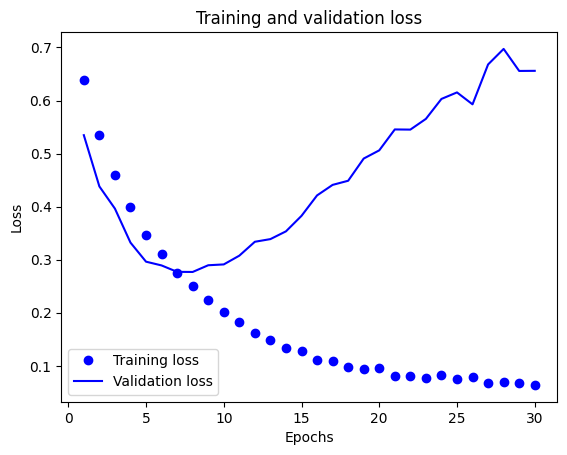

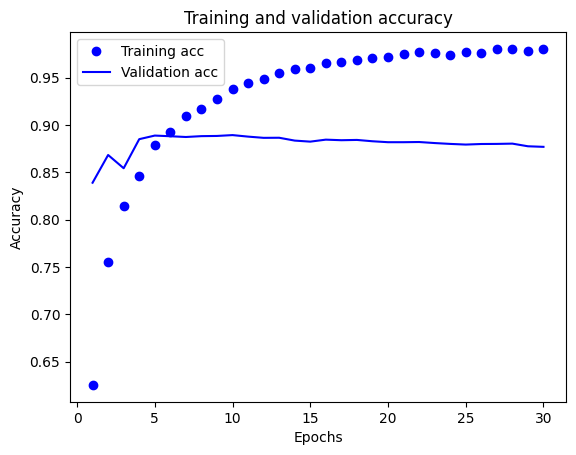

In [18]:
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]

epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.figure()
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Again we see a later and less extreme overfitting. Let us retrain the model on 7 epochs and test it.

In [19]:
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=7,
                    batch_size=512,
                    validation_data=(x_val, y_val))

test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.3f}")

Epoch 1/7
30/30 [==============================] - 5s 117ms/step - loss: 0.6520 - accuracy: 0.6170 - val_loss: 0.5999 - val_accuracy: 0.6201
Epoch 2/7
30/30 [==============================] - 1s 19ms/step - loss: 0.5732 - accuracy: 0.7637 - val_loss: 0.5368 - val_accuracy: 0.8197
Epoch 3/7
30/30 [==============================] - 1s 19ms/step - loss: 0.5189 - accuracy: 0.8352 - val_loss: 0.4958 - val_accuracy: 0.7948
Epoch 4/7
30/30 [==============================] - 1s 20ms/step - loss: 0.4765 - accuracy: 0.8685 - val_loss: 0.4674 - val_accuracy: 0.8333
Epoch 5/7
30/30 [==============================] - 1s 32ms/step - loss: 0.4377 - accuracy: 0.8931 - val_loss: 0.4444 - val_accuracy: 0.8536
Epoch 6/7
30/30 [==============================] - 1s 23ms/step - loss: 0.4120 - accuracy: 0.9019 - val_loss: 0.4207 - val_accuracy: 0.8786
Epoch 7/7
782/782 [==============================] - 2s 3ms/step - loss: 0.4145 - accuracy: 0.8740
Test accuracy: 0.874


Again, we did not manage to get a much better model in the end. It might suggest that overfitting is not as much of a problem for this model to begin with.

## Data augmentation

Data augmentation is something we usually do for computer vision models, so we need to look at the example of cats vs dogs again.

In [20]:
from keras.utils import image_dataset_from_directory

batch_size = 64
image_size = (180, 180)
train_dataset = image_dataset_from_directory(
    "dogs_vs_cats_tiny/train", image_size=image_size, batch_size=batch_size
)
validation_dataset = image_dataset_from_directory(
    "dogs_vs_cats_tiny/validation", image_size=image_size, batch_size=batch_size
)
test_dataset = image_dataset_from_directory(
    "dogs_vs_cats_tiny/test", image_size=image_size, batch_size=batch_size
)

Found 1200 files belonging to 2 classes.
Found 200 files belonging to 2 classes.
Found 600 files belonging to 2 classes.


In [21]:
c_and_d_model = keras.Sequential(
    [
        keras.Input(shape=(180, 180, 3)),
        layers.Rescaling(1.0/255),
        layers.Conv2D(filters=32, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(filters=64, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(filters=128, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(filters=256, kernel_size=3, activation="relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(1, activation="sigmoid"),
    ]
)

c_and_d_model.compile(optimizer="adam",
                      loss="binary_crossentropy",
                      metrics=["accuracy"])

In [22]:
history = c_and_d_model.fit(
    train_dataset,
    epochs=40,  # I have already checked when to stop...
    validation_data=validation_dataset)

Epoch 1/40
19/19 [==============================] - 11s 327ms/step - loss: 0.6945 - accuracy: 0.4942 - val_loss: 0.6934 - val_accuracy: 0.5000
Epoch 2/40
19/19 [==============================] - 3s 133ms/step - loss: 0.6859 - accuracy: 0.5242 - val_loss: 0.6822 - val_accuracy: 0.5900
Epoch 3/40
19/19 [==============================] - 1s 64ms/step - loss: 0.6843 - accuracy: 0.5492 - val_loss: 0.6773 - val_accuracy: 0.5500
Epoch 4/40
19/19 [==============================] - 1s 57ms/step - loss: 0.6762 - accuracy: 0.5650 - val_loss: 0.6952 - val_accuracy: 0.5200
Epoch 5/40
19/19 [==============================] - 1s 52ms/step - loss: 0.6872 - accuracy: 0.5492 - val_loss: 0.6822 - val_accuracy: 0.5750
Epoch 6/40
19/19 [==============================] - 1s 51ms/step - loss: 0.6504 - accuracy: 0.6175 - val_loss: 0.6711 - val_accuracy: 0.5900
Epoch 7/40
19/19 [==============================] - 1s 52ms/step - loss: 0.6419 - accuracy: 0.5983 - val_loss: 0.6645 - val_accuracy: 0.6000
Epoch 8/40

In [23]:
test_loss, test_acc = c_and_d_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

10/10 [==============================] - 1s 48ms/step - loss: 0.6709 - accuracy: 0.6967
Test accuracy: 0.697


To do data augmentation in keras we can add data augmentation layers to the start of our model. Here is an example of such data augmentation layers.

In [24]:
c_and_d_model_w_aug = keras.Sequential(
    [
        keras.Input(shape=(180, 180, 3)),
        layers.RandomFlip("horizontal"),    # Applies horizontal flipping to a random 50% of the images that go through it
        layers.RandomRotation(0.1),         # Rotates the input images by a random value in the range [–10%, +10%] (these are
                                            # fractions of a full circle—in degrees, the range would be [–36 degrees, +36 degrees])
        layers.RandomZoom(0.2),             # Zooms in or out of the image by a random factor in the range [-20%, +20%]
        layers.Rescaling(1.0/255),
        layers.Conv2D(filters=32, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(filters=64, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(filters=128, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(filters=256, kernel_size=3, activation="relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(1, activation="sigmoid"),
    ]
)

c_and_d_model_w_aug.compile(optimizer="adam",
                      loss="binary_crossentropy",
                      metrics=["accuracy"])

As we now expect less overfitting we will also train our model for a longer time.

In [25]:
history = c_and_d_model_w_aug.fit(
    train_dataset,
    epochs=44,
    validation_data=validation_dataset)

Epoch 1/44
19/19 [==============================] - 3s 59ms/step - loss: 0.6973 - accuracy: 0.5050 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 2/44
19/19 [==============================] - 1s 53ms/step - loss: 0.6925 - accuracy: 0.5000 - val_loss: 0.6914 - val_accuracy: 0.5050
Epoch 3/44
19/19 [==============================] - 1s 53ms/step - loss: 0.6949 - accuracy: 0.5258 - val_loss: 0.6924 - val_accuracy: 0.5400
Epoch 4/44
19/19 [==============================] - 1s 54ms/step - loss: 0.6917 - accuracy: 0.5292 - val_loss: 0.6919 - val_accuracy: 0.5000
Epoch 5/44
19/19 [==============================] - 1s 54ms/step - loss: 0.6895 - accuracy: 0.5483 - val_loss: 0.6870 - val_accuracy: 0.5450
Epoch 6/44
19/19 [==============================] - 1s 55ms/step - loss: 0.6795 - accuracy: 0.5750 - val_loss: 0.6898 - val_accuracy: 0.5300
Epoch 7/44
19/19 [==============================] - 1s 52ms/step - loss: 0.6659 - accuracy: 0.6008 - val_loss: 0.6774 - val_accuracy: 0.6200
Epoch 8/44
19

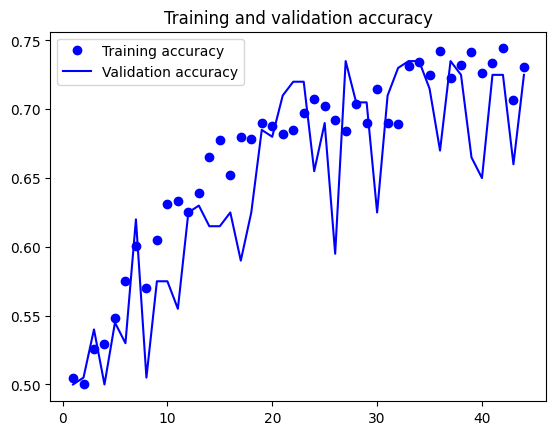

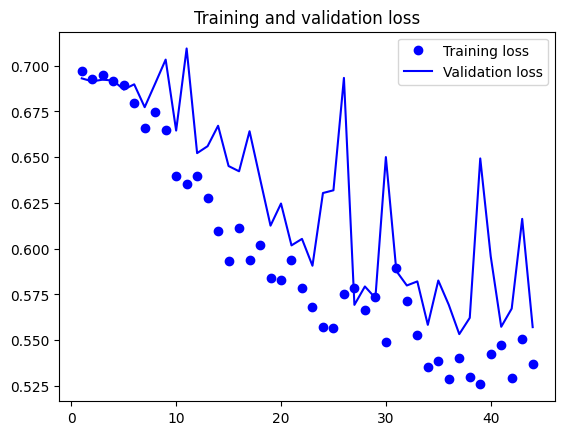

In [26]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Let us now evaluate it on the test dataset.

In [27]:
test_loss, test_acc = c_and_d_model_w_aug.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

10/10 [==============================] - 1s 48ms/step - loss: 0.6416 - accuracy: 0.6783
Test accuracy: 0.678


We see a clear improvement here! And if we made sure fit until the point just before overfitting, we might be able to do even better...

Now let us add it all together. That is, let us train the model with data augmentation, dropout and early stopping using callbacks.

In [28]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="cat_vs_dogs_final.keras",
        save_best_only=True,
        monitor="val_loss")
]

In [29]:
c_and_d_model_final = keras.Sequential(
    [
        keras.Input(shape=(180, 180, 3)),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
        layers.Rescaling(1.0/255),
        layers.Conv2D(filters=32, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(filters=64, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(filters=128, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(filters=256, kernel_size=3, activation="relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)

c_and_d_model_final.compile(optimizer="adam",
                      loss="binary_crossentropy",
                      metrics=["accuracy"])

As we expect much less overfitting we will also train for even longer now.

In [30]:
history = c_and_d_model_final.fit(
    train_dataset,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/100
19/19 [==============================] - 4s 68ms/step - loss: 0.6958 - accuracy: 0.4967 - val_loss: 0.6915 - val_accuracy: 0.5000
Epoch 2/100
19/19 [==============================] - 1s 53ms/step - loss: 0.6827 - accuracy: 0.5517 - val_loss: 0.6939 - val_accuracy: 0.5100
Epoch 3/100
19/19 [==============================] - 1s 59ms/step - loss: 0.6719 - accuracy: 0.5708 - val_loss: 0.6705 - val_accuracy: 0.5650
Epoch 4/100
19/19 [==============================] - 1s 53ms/step - loss: 0.6594 - accuracy: 0.6042 - val_loss: 0.6941 - val_accuracy: 0.5050
Epoch 5/100
19/19 [==============================] - 1s 58ms/step - loss: 0.6495 - accuracy: 0.5983 - val_loss: 0.6581 - val_accuracy: 0.5500
Epoch 6/100
19/19 [==============================] - 1s 59ms/step - loss: 0.6414 - accuracy: 0.6150 - val_loss: 0.6681 - val_accuracy: 0.5450
Epoch 7/100
19/19 [==============================] - 1s 52ms/step - loss: 0.6314 - accuracy: 0.6250 - val_loss: 0.6879 - val_accuracy: 0.5150
Epoch 

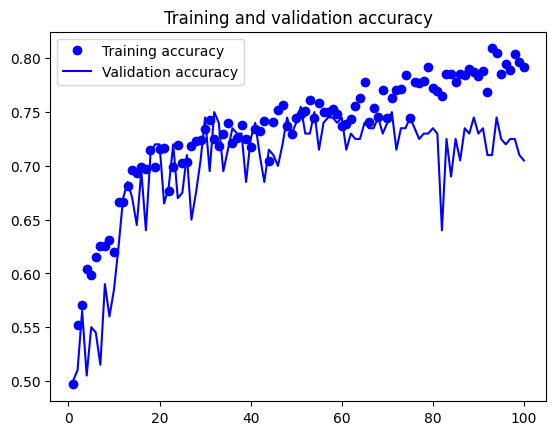

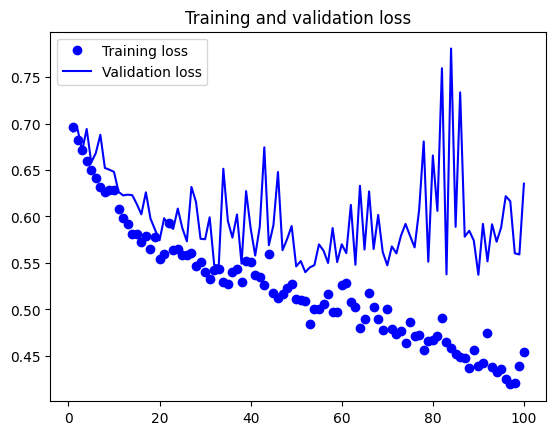

In [31]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

We see that we do not overfit until we reach close to 60 epochs.

Let us now test the best model.

In [32]:
test_model = keras.models.load_model("cat_vs_dogs_final.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

10/10 [==============================] - 0s 20ms/step - loss: 0.6602 - accuracy: 0.7083
Test accuracy: 0.708


We now see a significant improvement over the baseline model!